# Frequency Analysis

This notebook analyzes order and delivery patterns in the Olist e-commerce dataset using PostgreSQL.

The analysis focuses on:

- Monthly delivered order volume
- Cities with the highest number of orders
- Delivery patterns by hour
- Difference between estimated and actual delivery dates
- Average delivery time by customer state

All analytical calculations are performed in SQL, while Python is used for data retrieval and visualization.

In [1]:
import getpass
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, URL

password = getpass.getpass("PostgreSQL password: ")

connection_url = URL.create(
    "postgresql+psycopg2",
    username="laraolgun",
    password=password,
    host="localhost",
    database="olist"
)

engine = create_engine(connection_url)

print("Connected to PostgreSQL: olist")

Connected to PostgreSQL: olist


## 1. Monthly Delivered Orders

In [2]:
query = """
SELECT
    DATE_TRUNC('month', order_delivered_customer)::date AS month,
    COUNT(*) AS orders_delivered
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer IS NOT NULL
GROUP BY month
ORDER BY month;
"""

df_monthly_orders = pd.read_sql_query(query, engine)

df_monthly_orders

,month,orders_delivered
0,2016-10-01,205
1,2016-11-01,58
2,2016-12-01,4
3,2017-01-01,283
4,2017-02-01,1351
5,2017-03-01,2382
6,2017-04-01,1849
7,2017-05-01,3751
8,2017-06-01,3223
9,2017-07-01,3455


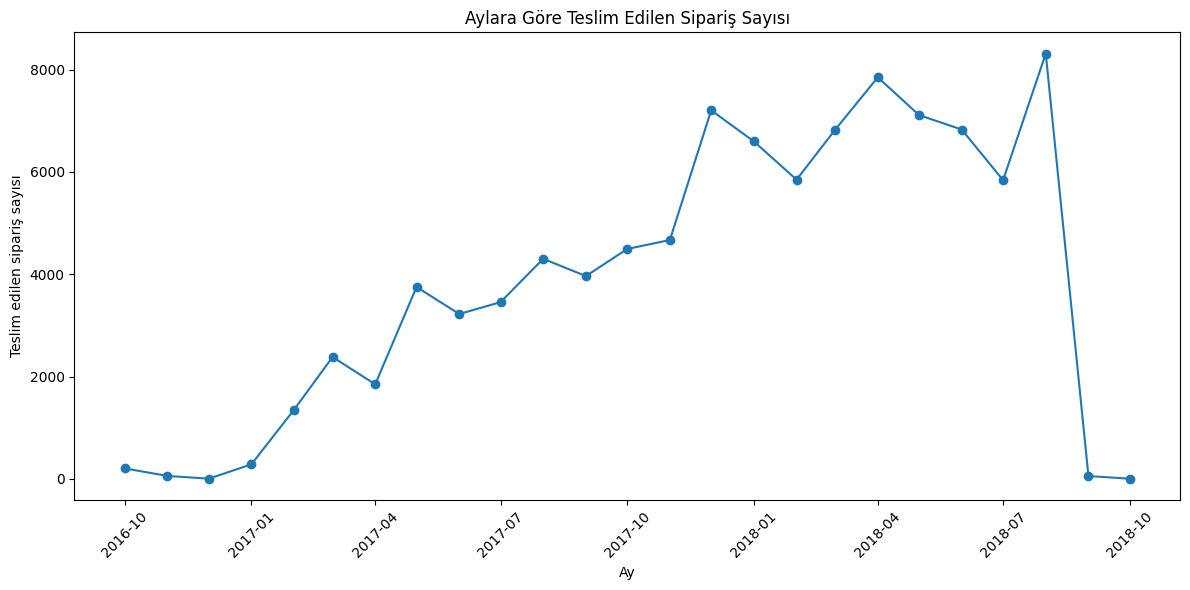

In [3]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_monthly_orders["month"],
    df_monthly_orders["orders_delivered"],
    marker="o"
)

plt.xlabel("Ay")
plt.ylabel("Teslim edilen sipariş sayısı")
plt.title("Aylara Göre Teslim Edilen Sipariş Sayısı")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Top 5 Cities by Order Count

In [4]:
query = """
SELECT
    c.customer_state,
    c.customer_city,
    COUNT(*) AS order_count
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
GROUP BY c.customer_state, c.customer_city
ORDER BY order_count DESC
LIMIT 5;
"""

df_top_cities = pd.read_sql_query(query, engine)

df_top_cities

,customer_state,customer_city,order_count
0,SP,sao paulo,15540
1,RJ,rio de janeiro,6882
2,MG,belo horizonte,2773
3,DF,brasilia,2131
4,PR,curitiba,1521


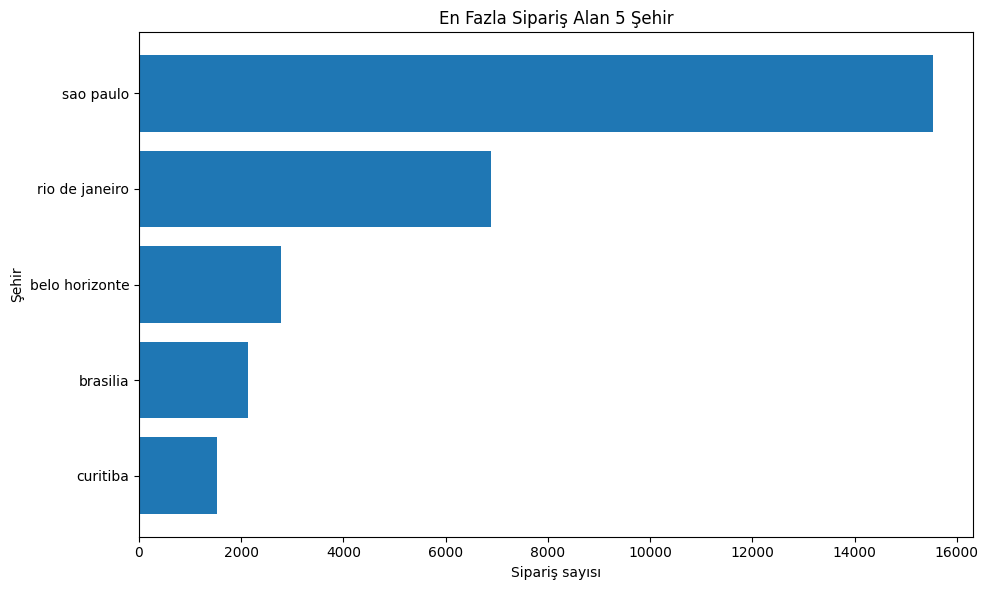

In [5]:
plt.figure(figsize=(10, 6))

plt.barh(
    df_top_cities["customer_city"][::-1],
    df_top_cities["order_count"][::-1]
)

plt.xlabel("Sipariş sayısı")
plt.ylabel("Şehir")
plt.title("En Fazla Sipariş Alan 5 Şehir")

plt.tight_layout()
plt.show()

## 3. Deliveries by Hour

In [6]:
query = """
SELECT
    EXTRACT(HOUR FROM order_delivered_customer)::int AS delivery_hour,
    COUNT(*) AS orders_delivered
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer IS NOT NULL
GROUP BY delivery_hour
ORDER BY delivery_hour;
"""

df_delivery_hours = pd.read_sql_query(query, engine)

df_delivery_hours

,delivery_hour,orders_delivered
0,0,2885
1,1,1515
2,2,649
3,3,260
4,4,187
5,5,198
6,6,269
7,7,396
8,8,779
9,9,1196


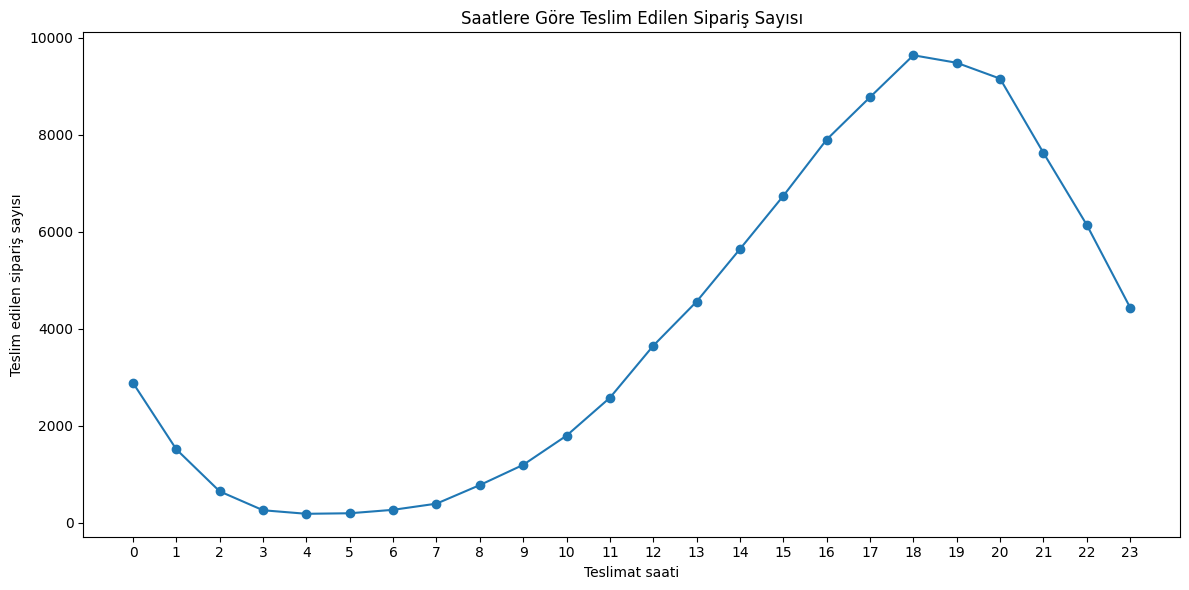

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_delivery_hours["delivery_hour"],
    df_delivery_hours["orders_delivered"],
    marker="o"
)

plt.xlabel("Teslimat saati")
plt.ylabel("Teslim edilen sipariş sayısı")
plt.title("Saatlere Göre Teslim Edilen Sipariş Sayısı")

plt.xticks(range(24))
plt.tight_layout()
plt.show()

## 4. Estimated vs Actual Delivery Difference

In [8]:
query = """
SELECT
    DATE_TRUNC('month', order_purchase)::date AS purchase_month,
    ROUND(
        AVG(
            EXTRACT(
                EPOCH FROM (
                    order_delivered_customer - order_estimated_delivery
                )
            ) / 86400
        )::numeric,
        2
    ) AS avg_delivery_difference_days
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer IS NOT NULL
  AND order_estimated_delivery IS NOT NULL
GROUP BY purchase_month
ORDER BY purchase_month;
"""

df_delivery_difference = pd.read_sql_query(query, engine)

df_delivery_difference

,purchase_month,avg_delivery_difference_days
0,2016-09-01,36.32
1,2016-10-01,-36.08
2,2016-12-01,-21.34
3,2017-01-01,-26.86
4,2017-02-01,-18.68
5,2017-03-01,-11.78
6,2017-04-01,-12.43
7,2017-05-01,-12.96
8,2017-06-01,-12.01
9,2017-07-01,-11.72


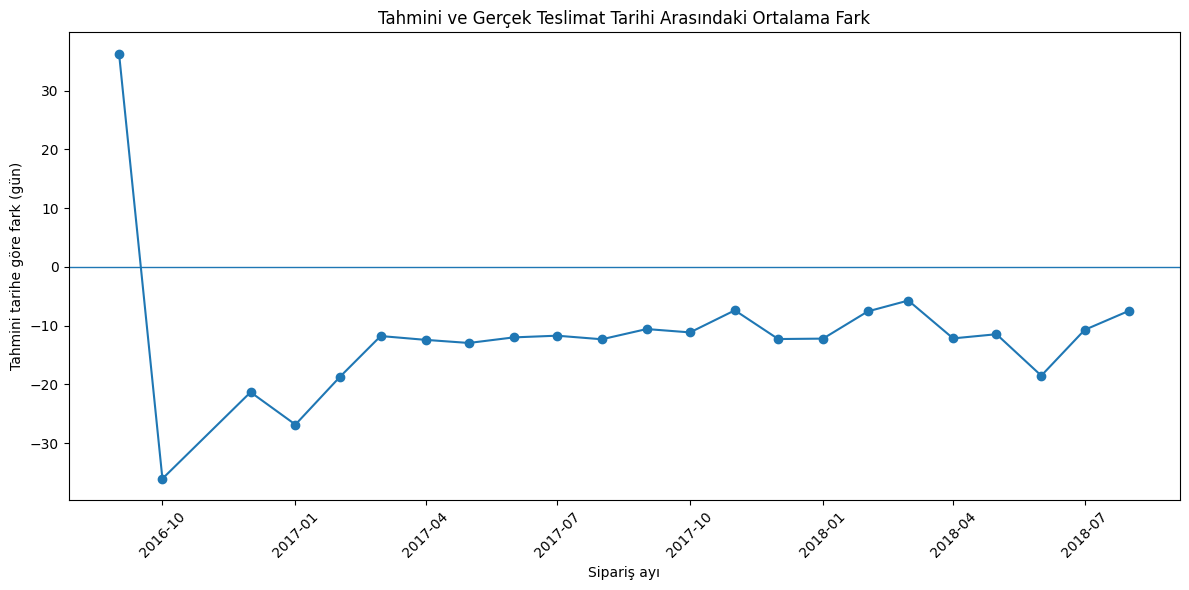

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_delivery_difference["purchase_month"],
    df_delivery_difference["avg_delivery_difference_days"],
    marker="o"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Sipariş ayı")
plt.ylabel("Tahmini tarihe göre fark (gün)")
plt.title("Tahmini ve Gerçek Teslimat Tarihi Arasındaki Ortalama Fark")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Average Delivery Time by State

In [10]:
query = """
SELECT
    c.customer_state,
    COUNT(*) AS delivered_orders,
    ROUND(
        AVG(
            EXTRACT(
                EPOCH FROM (o.order_delivered_customer - o.order_purchase)
            ) / 86400
        )::numeric,
        2
    ) AS avg_delivery_time_days
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
  AND o.order_purchase IS NOT NULL
  AND o.order_delivered_customer IS NOT NULL
GROUP BY c.customer_state
ORDER BY avg_delivery_time_days DESC;
"""

df_delivery_time = pd.read_sql_query(query, engine)

df_delivery_time

,customer_state,delivered_orders,avg_delivery_time_days
0,RR,41,29.39
1,AP,67,27.19
2,AM,145,26.43
3,AL,397,24.54
4,PA,946,23.77
5,MA,717,21.57
6,SE,335,21.52
7,CE,1279,21.27
8,AC,80,21.04
9,PB,517,20.43


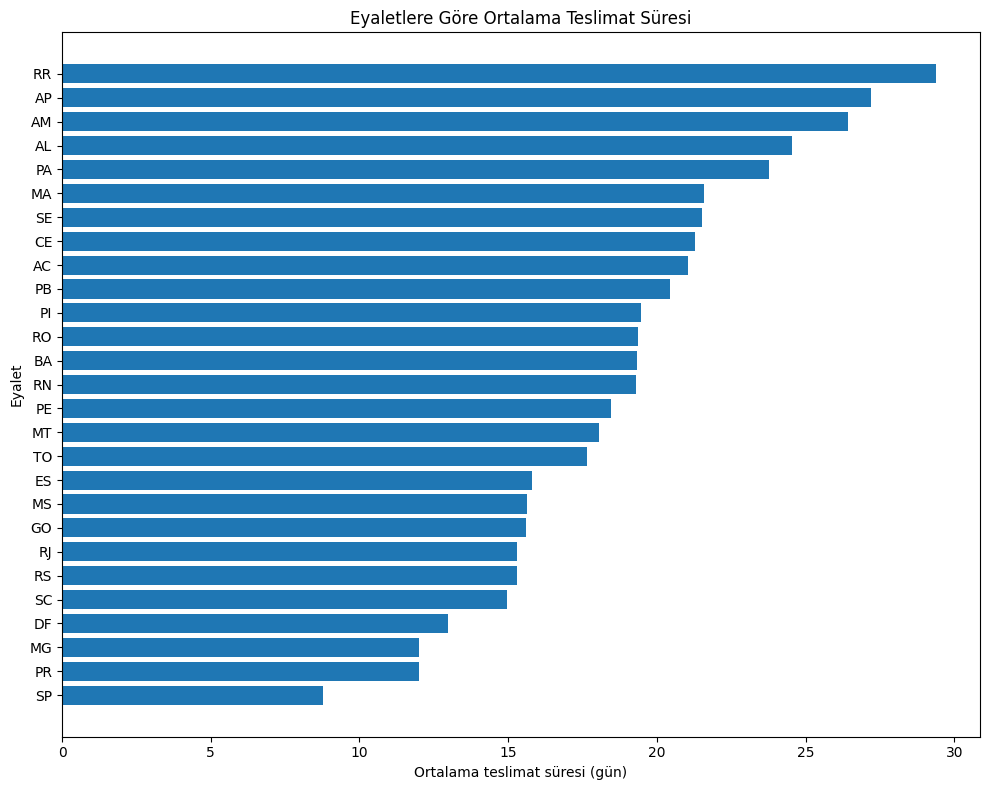

In [11]:
plt.figure(figsize=(10, 8))

plt.barh(
    df_delivery_time["customer_state"][::-1],
    df_delivery_time["avg_delivery_time_days"][::-1]
)

plt.xlabel("Ortalama teslimat süresi (gün)")
plt.ylabel("Eyalet")
plt.title("Eyaletlere Göre Ortalama Teslimat Süresi")

plt.tight_layout()
plt.show()

In [12]:
engine.dispose()